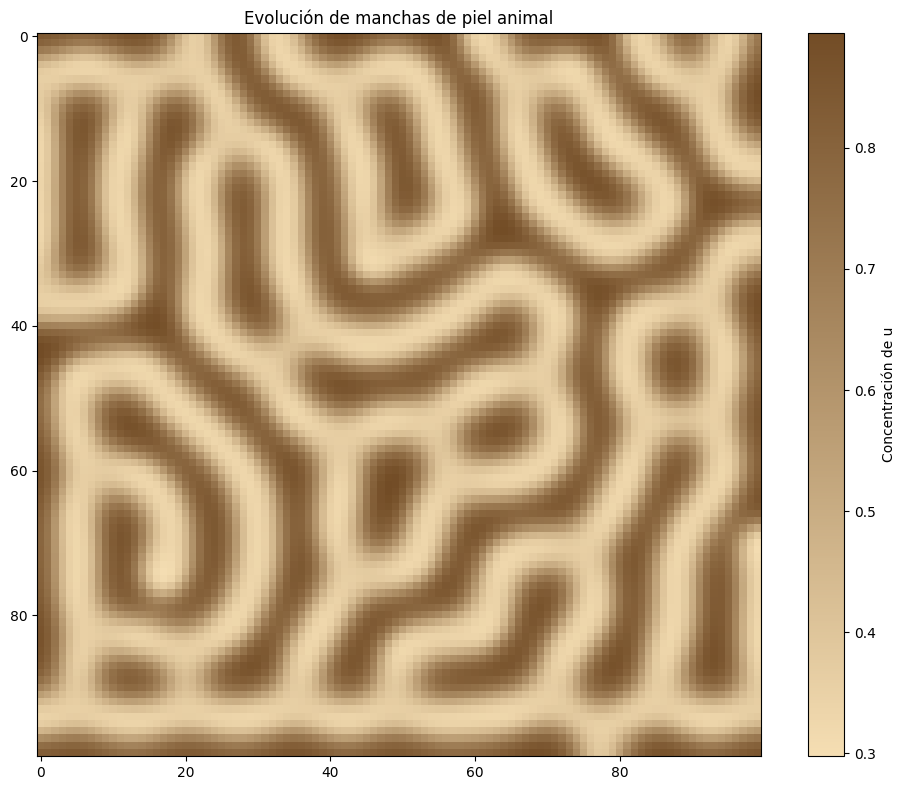

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from scipy.ndimage import laplace

# Parámetros para el modelo de Gray-Scott
def gray_scott_2d(u, v, Du, Dv, f, k, dt):
    # Aplicar laplaciano a ambas variables
    laplacian_u = laplace(u)
    laplacian_v = laplace(v)

    # Términos de reacción
    reaction_u = -u * v**2 + f * (1 - u)
    reaction_v = u * v**2 - (f + k) * v

    # Actualizar variables
    u_new = u + dt * (Du * laplacian_u + reaction_u)
    v_new = v + dt * (Dv * laplacian_v + reaction_v)

    return u_new, v_new

# Configuración del espacio y tiempo
size = 100  # Tamaño de la rejilla
steps = 10000  # Número de pasos de tiempo
dt = 1.0  # Paso de tiempo

# Conjunto de parámetros para simular manchas similares a las de leopardo
Du = 0.16  # Coeficiente de difusión de u
Dv = 0.08  # Coeficiente de difusión de v
f = 0.055  # Tasa de alimentación
k = 0.062  # Tasa de muerte

# Inicialización de las matrices u y v
u = np.ones((size, size))
v = np.zeros((size, size))

# Creación de una perturbación inicial en el centro
r = 20
center = size // 2
for i in range(size):
    for j in range(size):
        if ((i - center)**2 + (j - center)**2) < r**2:
            u[i, j] = 0.5
            v[i, j] = 0.25

# Agregamos algunas perturbaciones aleatorias
np.random.seed(42)  # Para reproducibilidad
for _ in range(10):
    x, y = np.random.randint(0, size, 2)
    for i in range(x-3, x+3):
        for j in range(y-3, y+3):
            if 0 <= i < size and 0 <= j < size:
                u[i, j] = 0.5
                v[i, j] = 0.25

# Definir el colormap para las manchas de animales
# Un color base como beige para el fondo y marrón oscuro para las manchas
colors = [(0.96, 0.87, 0.7), (0.45, 0.30, 0.15)]  # Beige a marrón oscuro
animal_spots_cmap = LinearSegmentedColormap.from_list("animal_spots", colors)

# Evolución del sistema y visualización
def run_simulation(animate=True):
    global u, v

    # Evolución del sistema
    for _ in range(steps):
        u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)

    if not animate:
        # Mostrar resultado final
        plt.figure(figsize=(10, 8))
        plt.imshow(u, cmap=animal_spots_cmap)
        plt.colorbar(label='Concentración de u')
        plt.title('Simulación de manchas de piel animal')
        plt.tight_layout()
        plt.show()
    else:
        # Configuración para animación
        fig, ax = plt.subplots(figsize=(10, 8))
        img = ax.imshow(u, cmap=animal_spots_cmap, animated=True)
        plt.colorbar(img, ax=ax, label='Concentración de u')
        plt.title('Evolución de manchas de piel animal')

        # Función de actualización para la animación
        def update(frame):
            global u, v
            for _ in range(20):  # Actualizamos 20 pasos por frame para ver cambios
                u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)
            img.set_array(u)
            return [img]

        # Crear la animación
        ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)
        plt.tight_layout()
        plt.show()

        # Opcional: guardar la animación
        # ani.save('manchas_piel_animal.gif', writer='pillow', fps=10)

# Ejecutar simulación con animación
run_simulation(animate=True)

# Ejemplo adicional: cambiar parámetros para obtener patrones diferentes
def try_different_patterns():
    global u, v, f, k

    # Reinicializar u y v
    u = np.ones((size, size))
    v = np.zeros((size, size))

    # Crear perturbación inicial
    r = 20
    center = size // 2
    for i in range(size):
        for j in range(size):
            if ((i - center)**2 + (j - center)**2) < r**2:
                u[i, j] = 0.5
                v[i, j] = 0.25

    # Agregar perturbaciones aleatorias
    for _ in range(10):
        x, y = np.random.randint(0, size, 2)
        for i in range(x-3, x+3):
            for j in range(y-3, y+3):
                if 0 <= i < size and 0 <= j < size:
                    u[i, j] = 0.5
                    v[i, j] = 0.25

    # Parámetros para rayas (como cebra)
    f = 0.026
    k = 0.059

    # Ejecutar la simulación
    for _ in range(steps):
        u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)

    # Mostrar resultado
    plt.figure(figsize=(10, 8))
    plt.imshow(u, cmap=animal_spots_cmap)
    plt.colorbar(label='Concentración de u')
    plt.title('Simulación de rayas de piel animal')
    plt.tight_layout()
    plt.show()

# Descomentar para probar patrones de rayas
# try_different_patterns()

Simulando patrones de piel de animal...
Mostrando etapas clave de evolución...


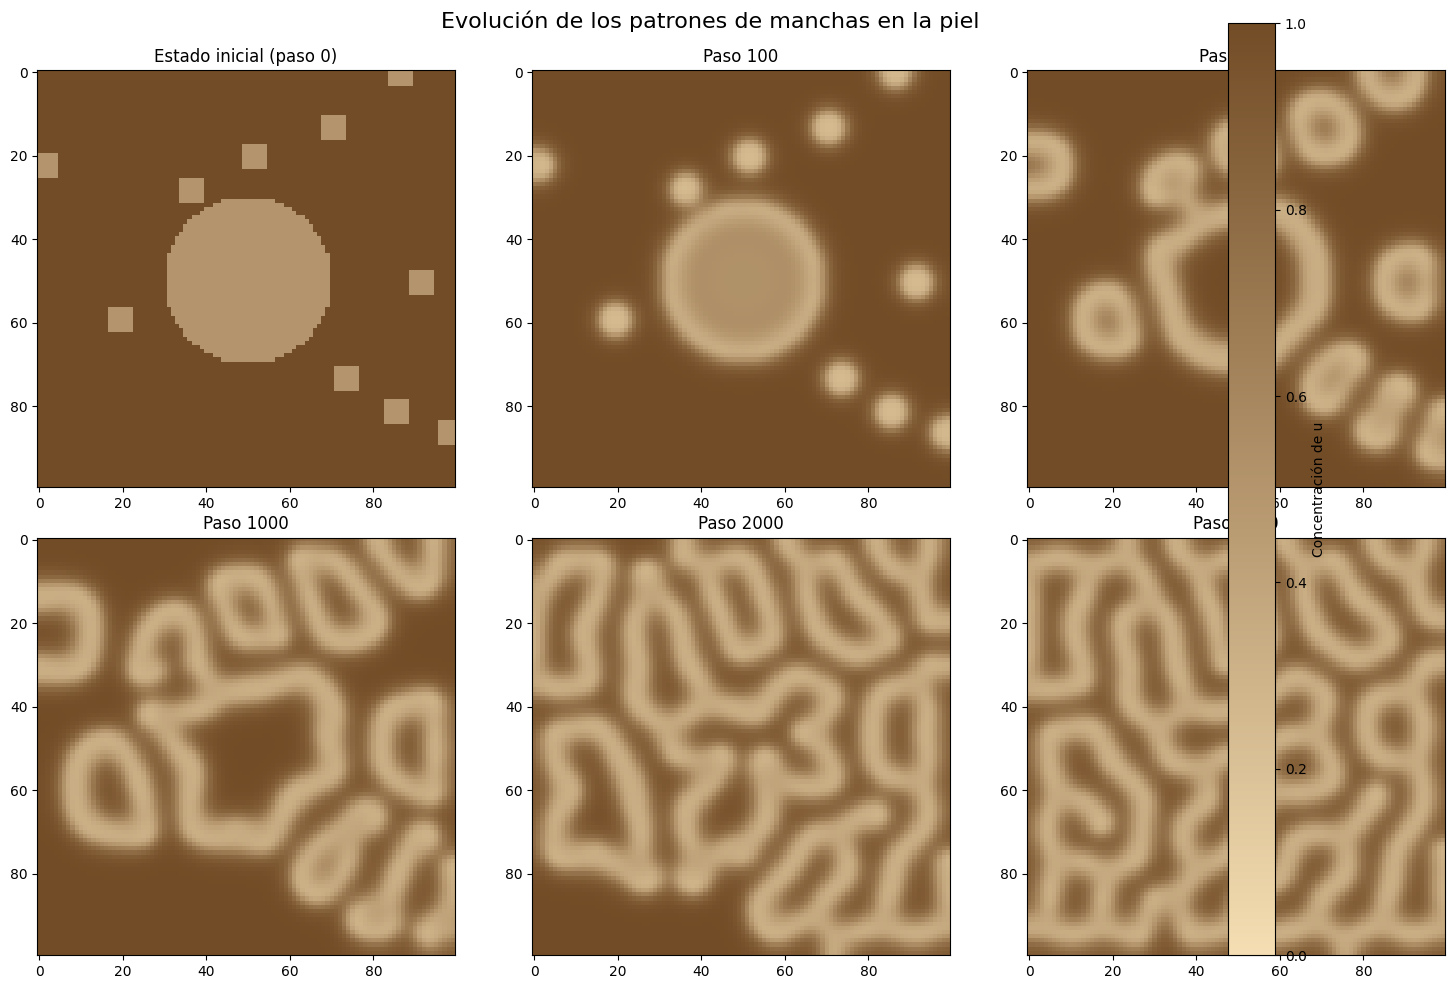

Iniciando animación de la evolución completa...


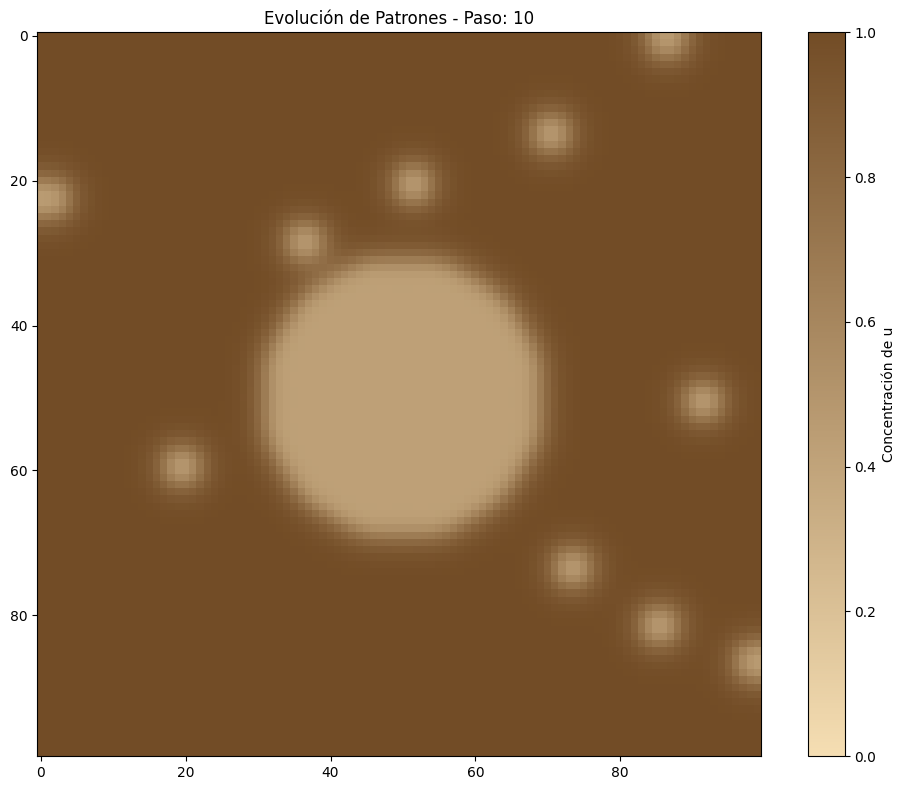

Simulación completada.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import laplace
import matplotlib as mpl

# Configuramos mejor visualización
plt.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['animation.embed_limit'] = 50  # Aumentar límite para animaciones más largas

# Parámetros para el modelo de Gray-Scott
def gray_scott_2d(u, v, Du, Dv, f, k, dt):
    # Aplicar laplaciano a ambas variables
    laplacian_u = laplace(u)
    laplacian_v = laplace(v)

    # Términos de reacción
    reaction_u = -u * v**2 + f * (1 - u)
    reaction_v = u * v**2 - (f + k) * v

    # Actualizar variables
    u_new = u + dt * (Du * laplacian_u + reaction_u)
    v_new = v + dt * (Dv * laplacian_v + reaction_v)

    return u_new, v_new

# Configuración del espacio y tiempo
size = 100  # Tamaño de la rejilla
dt = 1.0  # Paso de tiempo

# Conjunto de parámetros para simular manchas similares a las de leopardo
Du = 0.16  # Coeficiente de difusión de u
Dv = 0.08  # Coeficiente de difusión de v
f = 0.055  # Tasa de alimentación
k = 0.062  # Tasa de muerte

# Inicialización de las matrices u y v
u = np.ones((size, size))
v = np.zeros((size, size))

# Creación de una perturbación inicial en el centro
r = 20
center = size // 2
for i in range(size):
    for j in range(size):
        if ((i - center)**2 + (j - center)**2) < r**2:
            u[i, j] = 0.5
            v[i, j] = 0.25

# Agregamos algunas perturbaciones aleatorias para formar diferentes patrones
np.random.seed(42)  # Para reproducibilidad
for _ in range(10):
    x, y = np.random.randint(0, size, 2)
    for i in range(x-3, x+3):
        for j in range(y-3, y+3):
            if 0 <= i < size and 0 <= j < size:
                u[i, j] = 0.5
                v[i, j] = 0.25

# Guardar el estado inicial para la animación
u_initial = u.copy()
v_initial = v.copy()

# Definir el colormap para las manchas de animales
# Creamos un colormap más natural para piel de animal
colors = [(0.96, 0.87, 0.7), (0.45, 0.30, 0.15)]  # Beige a marrón oscuro
animal_spots_cmap = LinearSegmentedColormap.from_list("animal_spots", colors)

# Función para hacer una animación que muestre la evolución desde el inicio
def animate_evolution():
    # Reiniciar al estado inicial
    u = u_initial.copy()
    v = v_initial.copy()

    # Crear la figura para la animación
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.tight_layout()

    # Configuración inicial de la visualización
    img = ax.imshow(u, cmap=animal_spots_cmap, animated=True, vmin=0, vmax=1)
    title = ax.set_title('Evolución de Patrones - Paso: 0')
    cbar = fig.colorbar(img, ax=ax, label='Concentración de u')

    # Parámetros de la animación
    frames = 200  # Número total de frames
    steps_per_frame = 10  # Pasos de simulación por frame

    # Función de actualización para cada frame
    def update(frame):
        nonlocal u, v

        # Ejecutar varios pasos del modelo por cada frame
        for _ in range(steps_per_frame):
            u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)

        # Actualizar la imagen
        img.set_array(u)
        title.set_text(f'Evolución de Patrones - Paso: {(frame+1)*steps_per_frame}')

        return [img, title]

    # Crear la animación
    ani = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

    plt.tight_layout()
    plt.show()

    # Opcional: guardar la animación como gif o video
    # ani.save('evolucion_manchas_animal.gif', writer='pillow', fps=10)

    return ani

# Función para ver la evolución en etapas específicas
def show_evolution_stages():
    # Reiniciar al estado inicial
    u = u_initial.copy()
    v = v_initial.copy()

    # Definir etapas para mostrar (en número de pasos)
    stages = [0, 100, 500, 1000, 2000, 5000]

    # Crear subplots para cada etapa
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Mostrar el estado inicial
    im0 = axes[0].imshow(u, cmap=animal_spots_cmap, vmin=0, vmax=1)
    axes[0].set_title('Estado inicial (paso 0)')

    # Evolucionar y mostrar cada etapa
    current_step = 0
    for i, stage in enumerate(stages[1:], 1):
        # Evolucionar hasta la siguiente etapa
        steps_needed = stage - current_step
        for _ in range(steps_needed):
            u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)
        current_step = stage

        # Mostrar el resultado
        im = axes[i].imshow(u, cmap=animal_spots_cmap, vmin=0, vmax=1)
        axes[i].set_title(f'Paso {stage}')

    plt.tight_layout()
    fig.colorbar(im0, ax=axes.tolist(), label='Concentración de u')
    plt.suptitle('Evolución de los patrones de manchas en la piel', fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()

# Función principal para ejecutar la simulación con múltiples opciones
def run_simulation():
    print("Simulando patrones de piel de animal...")

    # Opción 1: Mostrar etapas clave de la evolución
    print("Mostrando etapas clave de evolución...")
    show_evolution_stages()

    # Opción 2: Mostrar animación completa
    print("Iniciando animación de la evolución completa...")
    ani = animate_evolution()

    print("Simulación completada.")
    return ani

# Ejecutar la simulación
animation = run_simulation()

# Función adicional para probar diferentes parámetros
def try_different_pattern(Du=0.16, Dv=0.08, f=0.026, k=0.059, description="rayas de cebra"):
    # Reinicializar u y v
    u = np.ones((size, size))
    v = np.zeros((size, size))

    # Crear perturbación inicial
    r = 20
    center = size // 2
    for i in range(size):
        for j in range(size):
            if ((i - center)**2 + (j - center)**2) < r**2:
                u[i, j] = 0.5
                v[i, j] = 0.25

    # Agregar perturbaciones aleatorias
    for _ in range(10):
        x, y = np.random.randint(0, size, 2)
        for i in range(x-3, x+3):
            for j in range(y-3, y+3):
                if 0 <= i < size and 0 <= j < size:
                    u[i, j] = 0.5
                    v[i, j] = 0.25

    # Guardar estado inicial
    u_initial = u.copy()
    v_initial = v.copy()

    # Crear la figura para la animación
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.tight_layout()

    # Configuración inicial de la visualización
    img = ax.imshow(u, cmap=animal_spots_cmap, animated=True, vmin=0, vmax=1)
    title = ax.set_title(f'Evolución de {description} - Paso: 0')
    cbar = fig.colorbar(img, ax=ax, label='Concentración de u')

    # Parámetros de la animación
    frames = 200  # Número total de frames
    steps_per_frame = 10  # Pasos de simulación por frame

    # Función de actualización para cada frame
    def update(frame):
        nonlocal u, v

        # Ejecutar varios pasos del modelo por cada frame
        for _ in range(steps_per_frame):
            u, v = gray_scott_2d(u, v, Du, Dv, f, k, dt)

        # Actualizar la imagen
        img.set_array(u)
        title.set_text(f'Evolución de {description} - Paso: {(frame+1)*steps_per_frame}')

        return [img, title]

    # Crear la animación
    ani = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

    plt.tight_layout()
    plt.show()

    return ani

# Descomentar para probar patrones de rayas
# rayas_animation = try_different_pattern(f=0.026, k=0.059, description="rayas de cebra")
# Descomentar para probar patrones de puntos pequeños (como guepardo)
# puntos_animation = try_different_pattern(f=0.082, k=0.059, description="puntos de guepardo")

Iniciando simulación de patrones de piel animal...
Progreso: 0/250 frames
Progreso: 0/250 frames
Animación creada. Mostrando evolución...


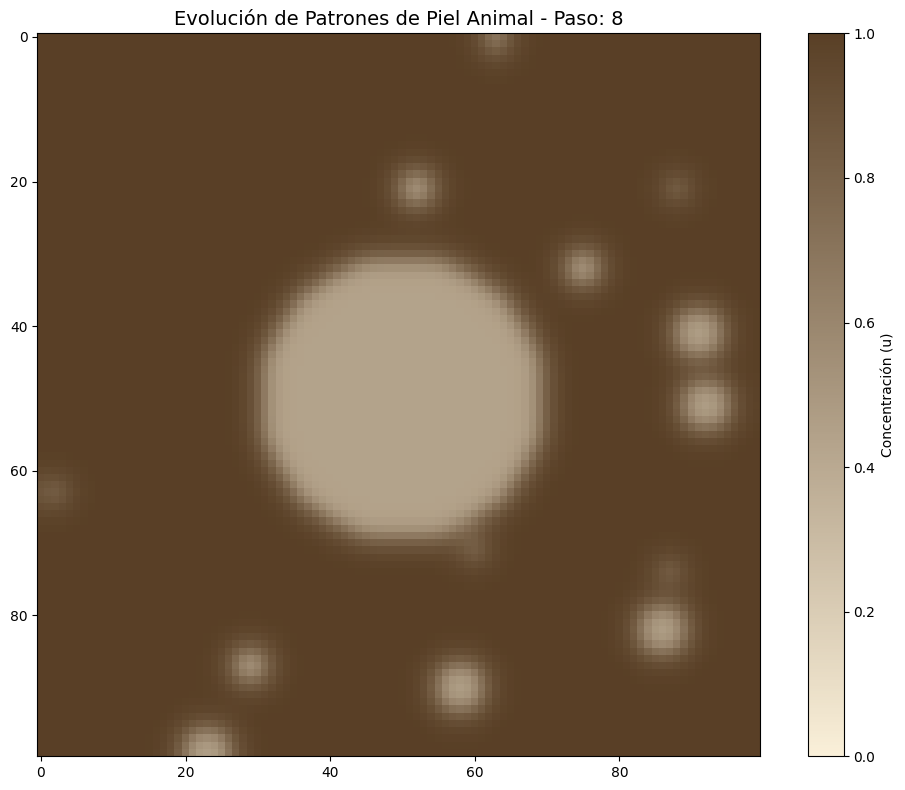

Simulación completada.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import laplace

# Parámetros para el modelo de Gray-Scott
def gray_scott_2d(u, v, Du, Dv, f, k, dt):
    # Aplicar laplaciano a ambas variables
    laplacian_u = laplace(u)
    laplacian_v = laplace(v)

    # Términos de reacción
    reaction_u = -u * v**2 + f * (1 - u)
    reaction_v = u * v**2 - (f + k) * v

    # Actualizar variables
    u_new = u + dt * (Du * laplacian_u + reaction_u)
    v_new = v + dt * (Dv * laplacian_v + reaction_v)

    return u_new, v_new

# Configuración del espacio y tiempo
size = 100  # Tamaño de la rejilla
dt = 1.0  # Paso de tiempo

# Conjunto de parámetros para simular manchas similares a las de leopardo
Du = 0.16  # Coeficiente de difusión de u
Dv = 0.08  # Coeficiente de difusión de v
f = 0.055  # Tasa de alimentación
k = 0.062  # Tasa de muerte

# Inicialización de las matrices u y v con valores base
u = np.ones((size, size))
v = np.zeros((size, size))

# Creación de perturbaciones iniciales más visibles
r = 20
center = size // 2

# Perturbación central
for i in range(size):
    for j in range(size):
        if ((i - center)**2 + (j - center)**2) < r**2:
            u[i, j] = 0.5
            v[i, j] = 0.25

# Perturbaciones aleatorias para crear más puntos de inicio
np.random.seed(42)  # Para reproducibilidad
for _ in range(15):  # Aumentamos a 15 perturbaciones para ver más patrones
    x, y = np.random.randint(0, size, 2)
    radius = np.random.randint(2, 5)  # Radio variable
    for i in range(x-radius, x+radius):
        for j in range(y-radius, y+radius):
            if 0 <= i < size and 0 <= j < size:
                if ((i - x)**2 + (j - y)**2) < radius**2:
                    u[i, j] = 0.5
                    v[i, j] = 0.25

# Definir colormap para las manchas de animal
# Un mapa de colores más natural y contrastante
colors = [(0.98, 0.94, 0.85), (0.35, 0.25, 0.15)]  # Beige claro a marrón oscuro
animal_spots_cmap = LinearSegmentedColormap.from_list("animal_spots", colors)

# Función para crear la animación
def create_animation():
    # Crear la figura
    fig, ax = plt.subplots(figsize=(10, 8))

    # Configuración inicial de la imagen
    img = ax.imshow(u, cmap=animal_spots_cmap, vmin=0, vmax=1, animated=True)

    # Añadir barra de color y título
    cbar = fig.colorbar(img, ax=ax, label='Concentración (u)')
    title = ax.set_title('Evolución de Patrones de Piel Animal - Paso: 0', fontsize=14)

    # Variables para la simulación
    frames = 250  # Total de frames para la animación
    steps_per_frame = 8  # Pasos de simulación por cada frame

    # Variables locales para la simulación
    u_current = u.copy()
    v_current = v.copy()

    # Función de actualización para cada frame
    def update(frame):
        nonlocal u_current, v_current

        # Ejecutar varios pasos del modelo por cada frame para ver cambios significativos
        for _ in range(steps_per_frame):
            u_current, v_current = gray_scott_2d(u_current, v_current, Du, Dv, f, k, dt)

        # Actualizar la imagen y el título con el paso actual
        img.set_array(u_current)
        paso_actual = (frame + 1) * steps_per_frame
        title.set_text(f'Evolución de Patrones de Piel Animal - Paso: {paso_actual}')

        if frame % 10 == 0:
            print(f"Progreso: {frame}/{frames} frames")

        return [img, title]

    # Crear la animación
    ani = FuncAnimation(fig, update, frames=frames, interval=40, blit=True)

    # Ajustar el layout
    plt.tight_layout()

    print("Animación creada. Mostrando evolución...")
    plt.show()

    # Opcional: guardar la animación (descomenta para guardar)
    # print("Guardando animación como GIF...")
    # ani.save('evolucion_manchas_animal.gif', writer='pillow', fps=15)

    return ani

# Ejecutar la simulación y mostrar la animación
print("Iniciando simulación de patrones de piel animal...")
animation = create_animation()
print("Simulación completada.")

# Función adicional para experimentar con diferentes patrones
def mostrar_otro_patron(tipo="rayas"):
    # Reinicializar matrices
    u_new = np.ones((size, size))
    v_new = np.zeros((size, size))

    # Crear perturbaciones iniciales
    for i in range(size):
        for j in range(size):
            if ((i - center)**2 + (j - center)**2) < r**2:
                u_new[i, j] = 0.5
                v_new[i, j] = 0.25

    # Añadir perturbaciones aleatorias
    for _ in range(15):
        x, y = np.random.randint(0, size, 2)
        radius = np.random.randint(2, 5)
        for i in range(x-radius, x+radius):
            for j in range(y-radius, y+radius):
                if 0 <= i < size and 0 <= j < size:
                    if ((i - x)**2 + (j - y)**2) < radius**2:
                        u_new[i, j] = 0.5
                        v_new[i, j] = 0.25

    # Establecer parámetros según el tipo de patrón
    if tipo == "rayas":
        Du_new = 0.16
        Dv_new = 0.08
        f_new = 0.026
        k_new = 0.059
        descripcion = "Rayas (similar a cebra)"
    elif tipo == "puntos_pequenos":
        Du_new = 0.16
        Dv_new = 0.08
        f_new = 0.082
        k_new = 0.059
        descripcion = "Puntos pequeños (similar a guepardo)"
    elif tipo == "moteado":
        Du_new = 0.16
        Dv_new = 0.08
        f_new = 0.035
        k_new = 0.065
        descripcion = "Patrón moteado (similar a jirafa)"
    else:
        # Parámetros por defecto (manchas de leopardo)
        Du_new = 0.16
        Dv_new = 0.08
        f_new = 0.055
        k_new = 0.062
        descripcion = "Manchas (similar a leopardo)"

    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 8))
    img = ax.imshow(u_new, cmap=animal_spots_cmap, vmin=0, vmax=1, animated=True)
    cbar = fig.colorbar(img, ax=ax, label='Concentración (u)')
    title = ax.set_title(f'Evolución de {descripcion} - Paso: 0', fontsize=14)

    # Parámetros de animación
    frames = 250
    steps_per_frame = 8

    # Función de actualización
    def update(frame):
        nonlocal u_new, v_new

        for _ in range(steps_per_frame):
            u_new, v_new = gray_scott_2d(u_new, v_new, Du_new, Dv_new, f_new, k_new, dt)

        img.set_array(u_new)
        paso_actual = (frame + 1) * steps_per_frame
        title.set_text(f'Evolución de {descripcion} - Paso: {paso_actual}')

        return [img, title]

    # Crear animación
    ani = FuncAnimation(fig, update, frames=frames, interval=40, blit=True)
    plt.tight_layout()
    plt.show()

    return ani

# Para ver otros patrones, descomentar las siguientes líneas:
# rayas_animation = mostrar_otro_patron("rayas")
# puntos_animation = mostrar_otro_patron("puntos_pequenos")
# moteado_animation = mostrar_otro_patron("moteado")